# Purpose

Calculate h_a for different combinations of Avobenzone and NPS absorber concentrations and various source spectra, including:

- 365 nm 
    - with 370 nm short pass filter
- 385 nm
    - full spectrum
    - 400 nm short pass filter
    - 390-400 nm band pass filter
- 405 nm
    - full spectrum
    - short pass filter
    - band pass filter
    - ~~Also try Sudan I with Avobenzone?~~
    
Use the Asahi calculated transmission data from 2021 for the bandpass filter.

Develop source spectrum manipulation tools to do the following:

- Shift spectrum left or right while filling in data on shifted end of spectrum so full wavelength range is available.
- Define filter transmission properties as a spectrum.
- Apply a filter to another spectrum (multiply two spectra--the filter transmission and the source spectrum).
    - Short pass
    - Band pass
- Define some filters
    - 370 nm short pass
    - Asahi calculated band pass
        - 10 nm band pass (380 nm with 10 nm width at 1% transmission bandwidth)
        - 15 nm band pass (360 nm with 15 nm width at 1% transmission bandwidth)
    - Constructed band pass

# Imports

In [1]:
import copy
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

from scipy.interpolate import interp1d
import scipy
print(scipy.__version__)

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams, find_index_of_nearest, find_index_of_max, shift, shift_peak_wavelength
from spectra.normalizeddose import NormalizedDose
from spectra.sourcespectrum import SourceSpectrum

1.8.1


# Code

In [2]:
def num_indices_to_shift(shift_nm, wavelengths_nm):
    # Assume wavelengths_nm is evenly sampled
    delta_lambda = wavelengths_nm[1] - wavelengths_nm[0]

    return int(np.rint(shift_nm / delta_lambda))

def shift_spectrum(shift_nm, wavelengths_nm, values, fill_value=None):
    num_shift = num_indices_to_shift(shift_nm, wavelengths_nm)
    # print(num_shift)
    if fill_value is None:
        fill_value = values[0] if num_shift > 0 else values[-1]
    # print(fill_value)
    return shift(values, num_shift, fill_value=fill_value)


In [3]:
class FilteredSpectrum(SourceSpectrum):
    
    def __init__(self, original_source, filter_data, shift_nm=0, name="Needs name"):
        """Assumes filter_data is evenly spaced in wavelength)
        """
        # Make sure filter_data has 2 columns (wavelength, transmission)
        assert filter_data.shape[1] == 2
        self.name = name
        self.original_source = original_source
        self.wavelength = np.copy(self.original_source.wavelength)
        self.power = np.copy(self.original_source.power)
        self.filter_data = filter_data
        self.shifted_filter_data = np.zeros_like(self.filter_data)
        self.shifted_filter_data[:, 0] = self.filter_data[:, 0]
        self.shifted_filter_data[:, 1] = shift_spectrum(
            shift_nm, 
            self.filter_data[:, 0],
            self.filter_data[:, 1]
        )
        self._filter_func = interp1d(
            self.shifted_filter_data[:, 0], 
            self.shifted_filter_data[:, 1], 
            bounds_error=False, 
            fill_value=1.0
        )
        self.filter_transmission = self._filter_func(self.wavelength)
        self.power *= self.filter_transmission


# `data` contents

In [4]:
help(data)

Help on package spectra.data in spectra:

NAME
    spectra.data

PACKAGE CONTENTS
    absorbers (package)
    sources (package)

DATA
    absorbers = {'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectr...
    absorbers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p...
    material_abbreviations = {'Avobenzone': 'Avo', 'BLS99-2': 'B99', 'BME'...
    monomers = {'HDDA': Monomer(/Users/nordin/Documents/Projects/3D_prin.....
    monomers_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p....
    photoinitiators = {'irgacure819_in_PEGDA_2017-04-13': <spectra.absorbe...
    photoinitiators_directory = PosixPath('/Users/nordin/Documents/Project...
    sources = {'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectr...
    sources_directory = PosixPath('/Users/nordin/Documents/Projects/3D_p.....

FILE
    /Users/nordin/Documents/Projects/3D_printer_spectra_repos/3dprinter_spectra_and_tools/spectra/data/__init__.py




In [5]:
data.sources

{'365nm_visitech_with_50mm_asahi_filter_2018-11-22': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1751dc0>,
 'Asiga_405nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1751fd0>,
 'HR1_385nm_100um_fiber-2016-12-14': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1751f70>,
 'HR2_385nm_2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a17701c0>,
 'HR3.2_365nm_370nm_short_pass_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1770220>,
 'HR3.2_365nm_no_filter-2019-12-31': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1770280>,
 'HR3.3_365nm_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a17702e0>,
 'HR3.3_365nm_no_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a1770340>,
 'HR3.3_365nm_through_tray_370nm_short_pass_filter-2020-03-23': <spectra.sourcespectrum.SourceSpectrum at 0x7fa8a17703a0>,
 'HR3.3_365nm_through_tray_no_filter-2020-03-23': <spectra.sourcespectrum.S

In [6]:
data.absorbers

{'avobenzone_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751a30>,
 'avobenzone_in_PEGDA_2020-01-20': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751b50>,
 'benetex_obplus_in PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751a60>,
 'bls99-2_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751ac0>,
 'ideal_uniform_absorber': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751c10>,
 'martius_yellow_in PEGDA_2020-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751a90>,
 'nps_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751c70>,
 'octocrylene_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751b80>,
 'phenazine_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751cd0>,
 'salicylaldehyde_in_PEGDA_2017-04-13': <spectra.absorberspectrum.AbsorberSpectrum at 0x7fa8a1751d00>,
 'sudanI_in_PEGDA_2017-04

# Common variables

In [7]:
wavelengths = np.linspace(*ArrayParams(300, 480, 361))

z_array_params = ArrayParams(0, 100, 201)

# wavelength_array_params=ArrayParams(300, 440, 281)

save_plot_figures = False

# Define resins

In [8]:
# Monomer
pegda = ResinConstituentMonomer(data.monomers['PEGDA'], 100)
# avobenzone = ResinConstituentAbsorber(
#     data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
#     2.0
# )

nps_1p5 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    1.5
)
nps_2p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    2.0
)
nps_3p0 = ResinConstituentAbsorber(
    data.absorbers['nps_in_PEGDA_2017-04-13'],
    3.0
)

avobenzone_1p0 = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    1.0
)
avobenzone_2p0 = ResinConstituentAbsorber(
    data.absorbers['avobenzone_in_PEGDA_2017-04-13'],
    2.0
)


irgacure819 = ResinConstituentAbsorber(
    data.photoinitiators['irgacure819_in_PEGDA_2017-04-13'],
    1.0
)

resin_nps_2p0 = Resin(monomers=pegda, absorbers=nps_2p0, photoinitiators=irgacure819)
resin_nps_3p0 = Resin(monomers=pegda, absorbers=nps_3p0, photoinitiators=irgacure819)

resin_avo_1p0 = Resin(monomers=pegda, absorbers=avobenzone_1p0, photoinitiators=irgacure819)
resin_avo_2p0 = Resin(monomers=pegda, absorbers=avobenzone_2p0, photoinitiators=irgacure819)

resin_avo2p0_nps2p0 = Resin(monomers=pegda, absorbers=[avobenzone_2p0, nps_2p0], photoinitiators=irgacure819)
resin_avo1p0_nps2p0 = Resin(monomers=pegda, absorbers=[avobenzone_1p0, nps_2p0], photoinitiators=irgacure819)


# 365 nm source

In [22]:
source_365nm = data.sources['HR3.2_365nm_no_filter-2019-12-31']
source_365nm_shortpass = data.sources['HR3.2_365nm_370nm_short_pass_filter-2019-12-31']

# 405 nm source

In [9]:
source_405nm = data.sources['Asiga_405nm_100um_fiber-2016-12-14']

## Compare with NPS 2% absorption spectrum

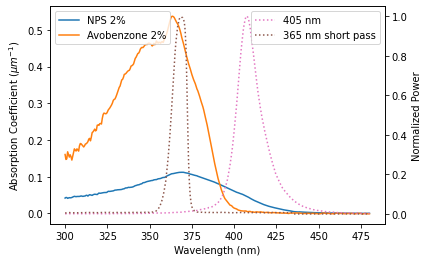

In [36]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.plot(wavelengths, resin_avo_2p0.calc_absorption_coef_inv_um(wavelengths), label='Avobenzone 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C6', ls=':', label='405 nm')
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C5', ls=':', label='365 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');

if save_plot_figures: plt.savefig('405nm_NPS_Avo.png')


## Normalized dose

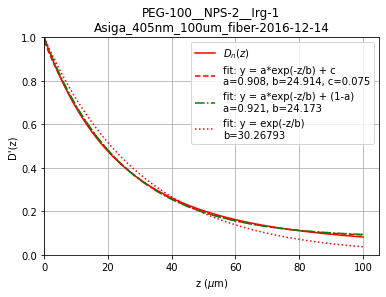

In [11]:
irradiance_405 = Irradiance(source=source_405nm, resin=resin_nps_2p0, wavelength_array_params=ArrayParams(300, 470, 601))
norm_dose_405 = NormalizedDose(irradiance=irradiance_405, z_array_params=z_array_params)

norm_dose_405.plot(title=(norm_dose_405.irradiance.resin.name + "\n" + norm_dose_405.irradiance.source.name));

if save_plot_figures: plt.savefig('NormDose_365nm_source.png')


# Short pass filter data

In [12]:
asahi_measured_data = np.genfromtxt('370nm shortpass filter_original.csv', delimiter=',', skip_header=2)

# Convert from percent to fractional transmission
asahi_measured_data[:, 1] = asahi_measured_data[:, 1]/100.

# Create filtered 405 nm spectrum

## 410 nm short pass filter

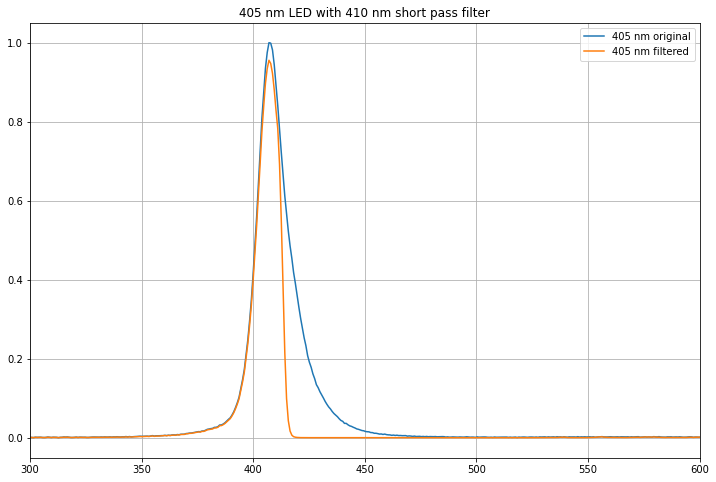

In [35]:
source_405nm_shortpass_410nm = FilteredSpectrum(source_405nm, asahi_measured_data, shift_nm=40, name="410 nm short pass")

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(source_405nm.wavelength, source_405nm.power, label="405 nm original")
ax.plot(source_405nm_shortpass_410nm.wavelength, source_405nm_shortpass_410nm.power, label="405 nm filtered")
# ax.plot(source_405nm_shortpass_410nm.wavelength, source_405nm_shortpass_410nm.filter_transmission, label="Filter")
# ax.plot(source_405nm_shortpass_410nm.filter_data[:, 0], source_405nm_shortpass_410nm.filter_data[:, 1], label="unshifted filter data")
ax.set_xlim(300, 600)
# ax.set_xlim(400, 450)
ax.set_title("405 nm LED with 410 nm short pass filter")
ax.grid()
ax.legend();

## 405 nm short pass filter

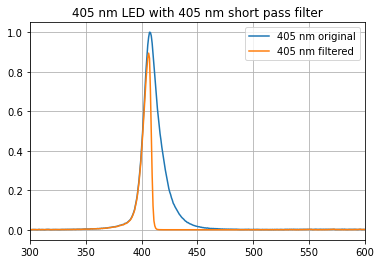

In [14]:
source_405nm_shortpass_405nm = FilteredSpectrum(source_405nm, asahi_measured_data, shift_nm=35, name="405 nm short pass")

fig, ax = plt.subplots()
ax.plot(source_405nm.wavelength, source_405nm.power, label="405 nm original")
ax.plot(source_405nm_shortpass_405nm.wavelength, source_405nm_shortpass_405nm.power, label="405 nm filtered")
# ax.plot(source_405nm_shortpass_405nm.wavelength, source_405nm_shortpass_405nm.filter_transmission, label="Filter")
# ax.plot(source_405nm_shortpass_410nm.filter_data[:, 0], source_405nm_shortpass_410nm.filter_data[:, 1], label="unshifted filter data")
ax.set_xlim(300, 600)
ax.set_title("405 nm LED with 405 nm short pass filter")
ax.grid()
ax.legend();

# NPS-only cases

## NPS 2% - 410 nm short pass filter

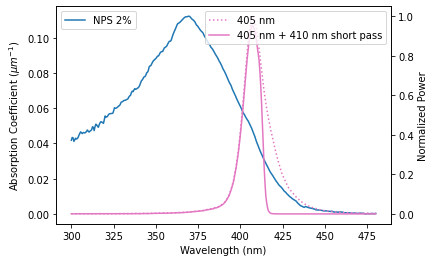

In [15]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C6', ls=':', label='405 nm')
ax2.plot(wavelengths, source_405nm_shortpass_410nm.calc_power(wavelengths), c='C6', label='405 nm + 410 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');


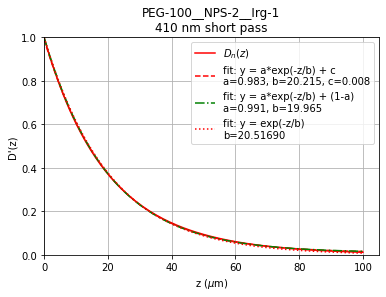

In [16]:
irradiance_405_shortpass_410nm = Irradiance(
    source=source_405nm_shortpass_410nm, 
    resin=resin_nps_2p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405_shortpass_410nm = NormalizedDose(irradiance=irradiance_405_shortpass_410nm, z_array_params=z_array_params)

norm_dose_405_shortpass_410nm.plot(
    title=(
        norm_dose_405_shortpass_410nm.irradiance.resin.name + 
        "\n" + 
        norm_dose_405_shortpass_410nm.irradiance.source.name
    )
);


## NPS 3% - 410 nm short pass filter

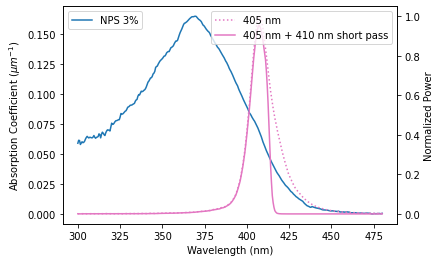

In [17]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_3p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 3%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C6', ls=':', label='405 nm')
ax2.plot(wavelengths, source_405nm_shortpass_410nm.calc_power(wavelengths), c='C6', label='405 nm + 410 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');


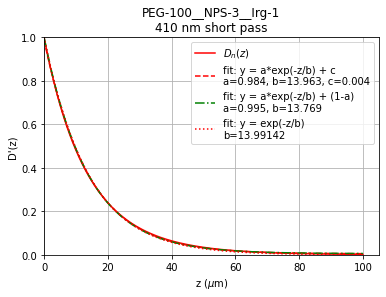

In [18]:
irradiance_405_shortpass_410nm_NPS_3 = Irradiance(
    source=source_405nm_shortpass_410nm, 
    resin=resin_nps_3p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405_shortpass_410nm_NPS_3 = NormalizedDose(
    irradiance=irradiance_405_shortpass_410nm_NPS_3, 
    z_array_params=z_array_params
)

norm_dose_405_shortpass_410nm_NPS_3.plot(
    title=(
        norm_dose_405_shortpass_410nm_NPS_3.irradiance.resin.name +
        "\n" +
        norm_dose_405_shortpass_410nm_NPS_3.irradiance.source.name
    )
);


## NPS 2% - 405 nm short pass filter

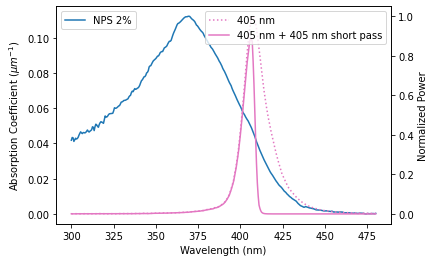

In [19]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C6', ls=':', label='405 nm')
ax2.plot(wavelengths, source_405nm_shortpass_405nm.calc_power(wavelengths), c='C6', label='405 nm + 405 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');


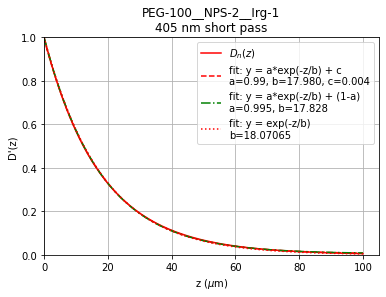

In [20]:
irradiance_405_shortpass_405nm = Irradiance(
    source=source_405nm_shortpass_405nm, 
    resin=resin_nps_2p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405_shortpass_405nm = NormalizedDose(irradiance=irradiance_405_shortpass_405nm, z_array_params=z_array_params)

norm_dose_405_shortpass_405nm.plot(
    title=(
        norm_dose_405_shortpass_405nm.irradiance.resin.name + 
        "\n" + 
        norm_dose_405_shortpass_405nm.irradiance.source.name
    )
);


## NPS 3% - 405 nm short pass filter

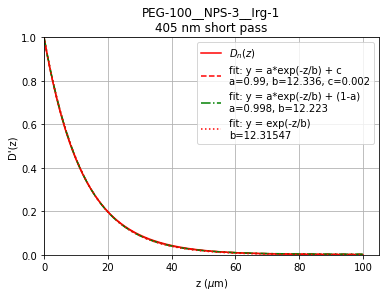

In [21]:
irradiance_405_shortpass_405nm = Irradiance(
    source=source_405nm_shortpass_405nm, 
    resin=resin_nps_3p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405_shortpass_405nm = NormalizedDose(irradiance=irradiance_405_shortpass_405nm, z_array_params=z_array_params)

norm_dose_405_shortpass_405nm.plot(
    title=(
        norm_dose_405_shortpass_405nm.irradiance.resin.name + 
        "\n" + 
        norm_dose_405_shortpass_405nm.irradiance.source.name
    )
);


# Avobenzone & NPS cases

## Avo 2%, NPS 2%

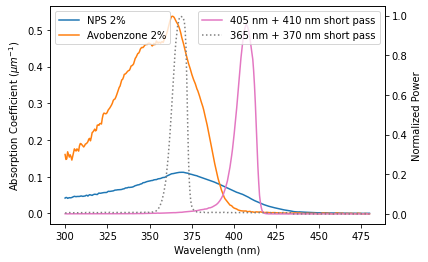

In [24]:
fig, ax = plt.subplots()
ax.plot(wavelengths, resin_nps_2p0.calc_absorption_coef_inv_um(wavelengths), label='NPS 2%')
ax.plot(wavelengths, resin_avo_2p0.calc_absorption_coef_inv_um(wavelengths), label='Avobenzone 2%')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)')
ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ax2.plot(wavelengths, source_405nm_shortpass_410nm.calc_power(wavelengths), c='C6', label='405 nm + 410 nm short pass')
ax2.plot(wavelengths, source_365nm_shortpass.calc_power(wavelengths), c='C7', ls=':', label='365 nm + 370 nm short pass')
ax2.set_ylabel('Normalized Power')
ax2.legend(loc='upper right');



### 405 nm with 410nm short pass filter

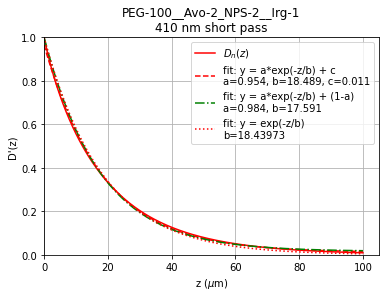

In [26]:
irradiance_405_shortpass_410nm_Avo2_NPS2 = Irradiance(
    source=source_405nm_shortpass_410nm, 
    resin=resin_avo2p0_nps2p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405_shortpass_410nm_Avo2_NPS2 = NormalizedDose(
    irradiance=irradiance_405_shortpass_410nm_Avo2_NPS2, 
    z_array_params=z_array_params
)

norm_dose_405_shortpass_410nm_Avo2_NPS2.plot(
    title=(
        norm_dose_405_shortpass_410nm_Avo2_NPS2.irradiance.resin.name +
        "\n" +
        norm_dose_405_shortpass_410nm_Avo2_NPS2.irradiance.source.name
    )
);


### 365 nm with 370 nm short pass filter

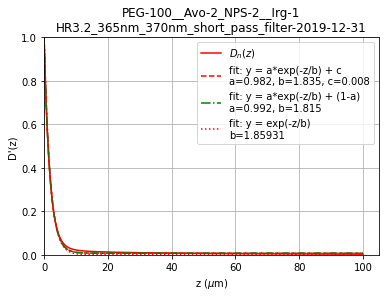

In [27]:
irradiance_365_shortpass_370nm_Avo2_NPS2 = Irradiance(
    source=source_365nm_shortpass, 
    resin=resin_avo2p0_nps2p0, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_365_shortpass_370nm_Avo2_NPS2 = NormalizedDose(
    irradiance=irradiance_365_shortpass_370nm_Avo2_NPS2, 
    z_array_params=z_array_params
)

norm_dose_365_shortpass_370nm_Avo2_NPS2.plot(
    title=(
        norm_dose_365_shortpass_370nm_Avo2_NPS2.irradiance.resin.name +
        "\n" +
        norm_dose_365_shortpass_370nm_Avo2_NPS2.irradiance.source.name
    )
);


In [28]:
15/18

0.8333333333333334

In [29]:
1.5/1.8

0.8333333333333333

# Next

- Try 405 nm short pass filter?
- Try Avobenzone added to the following and look at h_a for filtered 365 nm & filtered 405 nm:
    - 1.5% NPS?
    - 2% NPS
    - 3% NPS